In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl") # if you have the package installed, you can directly do using TensorBinding
using .TensorBinding

## Y-junction LDOS

Three 1D chains sharing a common junction site (Y-junction).
The TJunction branch index is stored in `H.sublattice_s` (dim-3, postpended),
so the existing `proj_sl` interface in `get_ldos_spatial` selects individual branches.

| `proj_sl` | Branch |
|-----------|--------|
| `1` | 0° |
| `2` | 120° |
| `3` | 240° |

`get_ldos_spatial` with `num_x=H.N` returns shape `(Nω, 3N)` — columns interleaved
`[Br1₀, Br2₀, Br3₀, Br1₁, Br2₁, Br3₁, …]`.
With `proj_sl=k` only branch-`k` columns are non-zero.
Column index `j` equals atom index `j` (both 1-indexed), so `H.geometry(j)` gives
the 2D position of the atom in column `j`.

In [2]:
# ── Build Hamiltonian ─────────────────────────────────────────────────────────
L             = 4     # 2^L sites per arm (N=16)
t             = 1.0   # intra-chain NN hopping
t_j           = 0.5   # junction coupling
junction_site = 0     # 0-indexed; junction at the left end of each arm

H = TensorBinding.tjunction_hamiltonian(L, t, t_j; junction_site=junction_site)

println(H)
println("Sites per arm : N = ", H.N, "  (2^$L)")
println("Total atoms   : ",     3*H.N, "  (3 arms × N)")
println("H.sublattice_s: ",     H.sublattice_s, "  ← TJunction branch (dim=3)")

TBHamiltonian | L=4, N=16 +3sublattices, scale=3.5, maxlinkdim=4 | geometry: 16 sites, 2D | no Tn cache
Sites per arm : N = 16  (2^4)
Total atoms   : 48  (3 arms × N)
H.sublattice_s: (dim=3|id=909|"TJunction")  ← TJunction branch (dim=3)


In [3]:
# ── Geometry helpers ──────────────────────────────────────────────────────────
#
# Atom convention (TJunction_tk.jl, branch-fast):
#   atom i (1-indexed) → chain_pos n = (i-1)÷3  (0-indexed)
#                         branch    s = (i-1)%3+1 (1/2/3)
#
# get_ldos_spatial with num_x=H.N, proj_sl=k → shape (Nω, 3N):
#   column  n*3 + k  ↔  atom index  n*3 + k  ↔  H.geometry(n*3 + k)
# so column index = atom index directly.

"""Return all 2D atom positions as a (3N × 2) matrix (branch-fast order)."""
function tj_all_positions(H)
    N_tot = 3 * H.N
    pos   = Matrix{Float64}(undef, N_tot, 2)
    for i in 1:N_tot
        pos[i, :] = H.geometry(i)
    end
    return pos
end

"""
    tj_ldos_scatter(H, ldos_b1, ldos_b2, ldos_b3, ω_list, ω0)
        -> (xs, ys, vals)

Combine per-branch LDOS matrices into one scatter dataset at energy ω0.
Each ldos_bk has non-zero entries only at branch-k columns; their sum covers
all atoms with no double-counting.
"""
function tj_ldos_scatter(H, ldos_b1, ldos_b2, ldos_b3, ω_list, ω0)
    i_ω  = argmin(abs.(collect(ω_list) .- ω0))
    pos  = tj_all_positions(H)
    vals = ldos_b1[i_ω, :] .+ ldos_b2[i_ω, :] .+ ldos_b3[i_ω, :]
    return pos[:, 1], pos[:, 2], vals
end

# Quick sanity-check: print junction + first arm-step positions
pos = tj_all_positions(H)
for (i, label) in [(1,"n=0 br=1 (junction)"),(2,"n=0 br=2 (junction)"),(3,"n=0 br=3 (junction)"),
                   (4,"n=1 br=1"),(5,"n=1 br=2"),(6,"n=1 br=3")]
    println("Atom $i ($label): ", round.(pos[i,:]; digits=3))
end

Atom 1 (n=0 br=1 (junction)): [0.0, 0.0]
Atom 2 (n=0 br=2 (junction)): [-0.0, 0.0]
Atom 3 (n=0 br=3 (junction)): [-0.0, -0.0]
Atom 4 (n=1 br=1): [1.0, 0.0]
Atom 5 (n=1 br=2): [-0.5, 0.866]
Atom 6 (n=1 br=3): [-0.5, -0.866]


In [4]:
# ── Compute per-branch LDOS ───────────────────────────────────────────────────
# H.sublattice_s is auto-detected → sublat_proj auto-enabled.
# proj_sl=k selects branch k; output shape: (Nω, 3N).

ω_list = range(-3.0, 3.0; length=200)
Ncheb  = 100

ldos_b1 = TensorBinding.get_ldos_spatial(H, Ncheb, ω_list;
    proj_sl=1, num_x=H.N, mode=:mpo, maxdim=50)

ldos_b2 = TensorBinding.get_ldos_spatial(H, Ncheb, ω_list;
    proj_sl=2, num_x=H.N, mode=:mpo, maxdim=50)

ldos_b3 = TensorBinding.get_ldos_spatial(H, Ncheb, ω_list;
    proj_sl=3, num_x=H.N, mode=:mpo, maxdim=50)

dos = TensorBinding.get_dos_stochastic(H, Ncheb, ω_list;
    N_sample=30, seed=42, maxdim=50, normalize=true)

println("LDOS shape : ", size(ldos_b1), "  (Nω × 3N)")
println("Non-zero cols of ldos_b1 at ω≈0 (first 9): ",
    findall(>(0), ldos_b1[length(ω_list)÷2, :])[1:min(9, end)])

Info: H.sublattice_s detected; auto-enabling sublat_proj=true (pass proj_sl=k to select a sublattice).
Info: H.sublattice_s detected; auto-enabling sublat_proj=true (pass proj_sl=k to select a sublattice).
Info: H.sublattice_s detected; auto-enabling sublat_proj=true (pass proj_sl=k to select a sublattice).
LDOS shape : (200, 48)  (Nω × 3N)
Non-zero cols of ldos_b1 at ω≈0 (first 9): [1, 4, 7, 10, 13, 16, 19, 22, 25]


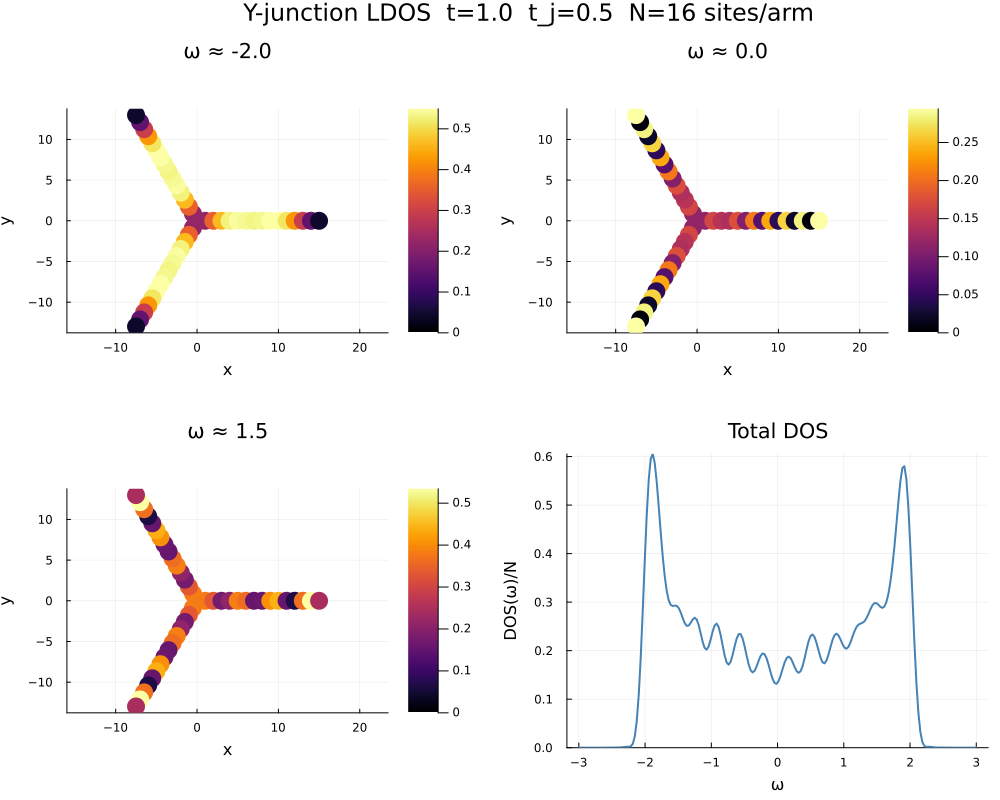

In [5]:
# ── 2D geometry scatter at selected energies + DOS ────────────────────────────
ω_probe = [-2.0, 0.0, 1.5]

geo_plots = map(ω_probe) do ω0
    xs, ys, vals = tj_ldos_scatter(H, ldos_b1, ldos_b2, ldos_b3, ω_list, ω0)
    clim = (0, max(1e-12, maximum(vals)))
    scatter(xs, ys;
        marker_z          = vals,
        color             = :inferno,
        clims             = clim,
        markersize        = 10,
        markerstrokewidth = 0,
        aspect_ratio      = :equal,
        colorbar          = true,
        xlabel = "x", ylabel = "y",
        title  = "ω ≈ $(round(ω0; digits=2))",
        label  = "")
end

p_dos = plot(ω_list, dos;
    title = "Total DOS", xlabel = "ω", ylabel = "DOS(ω)/N",
    lw = 2, color = :steelblue, label = "", ylims = (0, Inf))

plot(geo_plots..., p_dos;
    layout    = (2, 2),
    size      = (1000, 800),
    plot_title = "Y-junction LDOS  t=$t  t_j=$t_j  N=$(H.N) sites/arm")

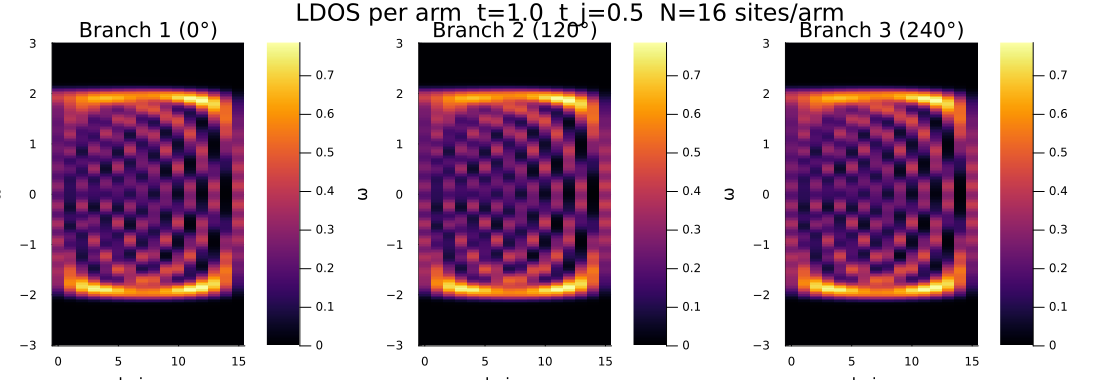

In [6]:
# ── Per-arm LDOS heatmaps (energy × chain position) ───────────────────────────
# Branch k occupies columns k, k+3, k+6, … in the (Nω, 3N) output.
hm_b1 = ldos_b1[:, 1:3:end]   # (Nω × N)
hm_b2 = ldos_b2[:, 2:3:end]
hm_b3 = ldos_b3[:, 3:3:end]

clim_hm  = (0, maximum(max.(hm_b1, hm_b2, hm_b3)))
chain_xs = 0:H.N-1   # 0-indexed chain positions

ph1 = heatmap(chain_xs, collect(ω_list), hm_b1;
    title="Branch 1 (0°)",   xlabel="chain pos", ylabel="ω",
    color=:inferno, clims=clim_hm)
ph2 = heatmap(chain_xs, collect(ω_list), hm_b2;
    title="Branch 2 (120°)", xlabel="chain pos", ylabel="ω",
    color=:inferno, clims=clim_hm)
ph3 = heatmap(chain_xs, collect(ω_list), hm_b3;
    title="Branch 3 (240°)", xlabel="chain pos", ylabel="ω",
    color=:inferno, clims=clim_hm)

plot(ph1, ph2, ph3;
    layout     = (1, 3),
    size       = (1100, 380),
    plot_title = "LDOS per arm  t=$t  t_j=$t_j  N=$(H.N) sites/arm")